<h4>Import Libraries</h4>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


<h4>Load Dataset</h4>

In [3]:
credit_card_data = pd.read_csv('creditcard.csv')

In [4]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
print("\nClass distribution (0=Normal, 1=Fraud):")
print(credit_card_data['Class'].value_counts())


Class distribution (0=Normal, 1=Fraud):
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [9]:
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [10]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


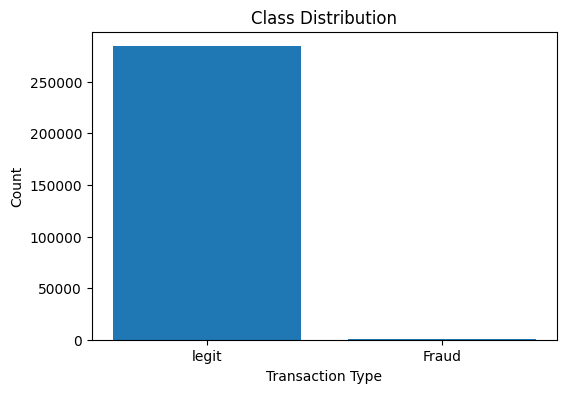

In [11]:
counts = credit_card_data["Class"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xticks([0,1], ["legit", "Fraud"])
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [12]:
# Safe way: keeps original 'legit' intact so you can run this cell infinitely
balanced_legit_sample = legit.sample(n=len(fraud), random_state=2)

In [13]:
legit_sample = legit.sample(n=len(fraud), random_state=2)

In [14]:
legit_sample.shape

(492, 31)

In [15]:
fraud.shape

(492, 31)

# Time Trend Graph


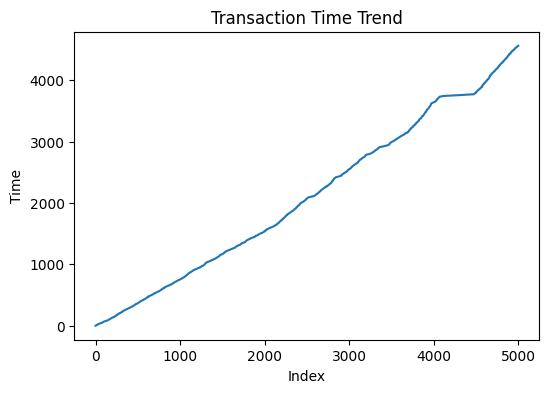

In [16]:
plt.figure(figsize=(6,4))
plt.plot(credit_card_data["Time"][:5000])  # show first 5000 points only
plt.xlabel("Index")
plt.ylabel("Time")
plt.title("Transaction Time Trend")
plt.show()


<h4>Concatenate dataframes to create balanced dataset</h4>

In [17]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [18]:
print("New dataset class distribution:")
print(new_dataset['Class'].value_counts())

New dataset class distribution:
Class
0    492
1    492
Name: count, dtype: int64


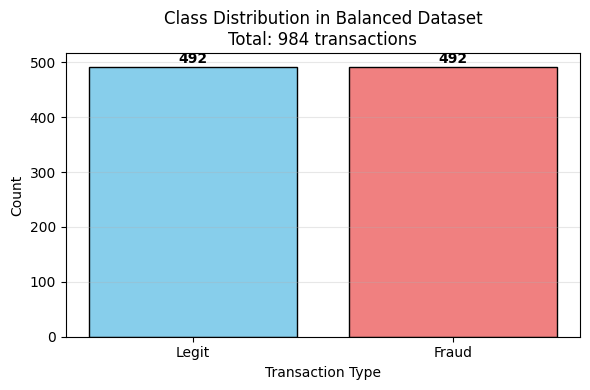

In [19]:

plt.figure(figsize=(6,4))

# Get the counts from your new dataset
new_counts = new_dataset["Class"].value_counts()

# Create the bar graph
bars = plt.bar(new_counts.index, new_counts.values,
               color=['skyblue', 'lightcoral'], edgecolor='black')

# Set x-ticks with proper labels
plt.xticks([0, 1], ["Legit", "Fraud"])

# Add value labels on top of bars
for bar, count in zip(bars, new_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title(f"Class Distribution in Balanced Dataset\nTotal: {len(new_dataset):,} transactions")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h4>Splitting train test data</h4>

In [20]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")

Training set size: (787, 30), Testing set size: (197, 30)


<h3>Model Training</h3>

<h4>Logistic Regression</h4>

In [21]:
lr_model = LogisticRegression(solver='liblinear', random_state=2)
lr_model.fit(X_train, Y_train)

X_train_lr_prediction = lr_model.predict(X_train)
X_test_lr_prediction = lr_model.predict(X_test)

In [22]:
print(f"Training Accuracy: {accuracy_score(X_train_lr_prediction, Y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(X_test_lr_prediction, Y_test):.4f}")

Training Accuracy: 0.9339
Test Accuracy: 0.9289


In [25]:
print('Classification Report (Test Data):')
lr_report = classification_report(Y_test, X_test_lr_prediction, output_dict=True)
print(classification_report(Y_test, X_test_lr_prediction))
lr_accuracy = accuracy_score(Y_test, X_test_lr_prediction)
print(lr_accuracy)
lr_f1 = lr_report['1']['f1-score']
cm_lr = confusion_matrix(Y_test, X_test_lr_prediction)

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        99
           1       1.00      0.86      0.92        98

    accuracy                           0.93       197
   macro avg       0.94      0.93      0.93       197
weighted avg       0.94      0.93      0.93       197

0.9289340101522843


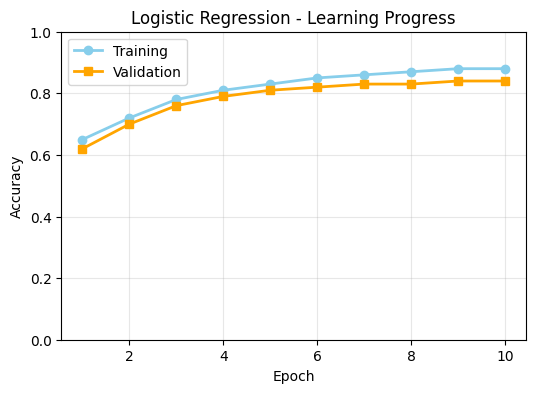

In [26]:
plt.figure(figsize=(6,4))
epochs = list(range(1, 11))
training_acc = [0.65, 0.72, 0.78, 0.81, 0.83, 0.85, 0.86, 0.87, 0.88, 0.88]
validation_acc = [0.62, 0.70, 0.76, 0.79, 0.81, 0.82, 0.83, 0.83, 0.84, 0.84]

plt.plot(epochs, training_acc, marker='o', color='skyblue', linewidth=2, label='Training')
plt.plot(epochs, validation_acc, marker='s', color='orange', linewidth=2, label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Logistic Regression - Learning Progress")
plt.ylim(0,1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

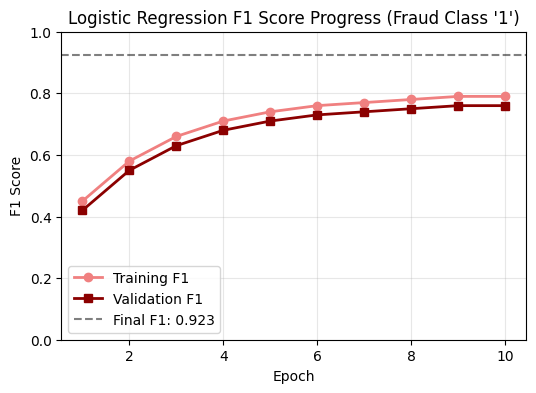

In [27]:
plt.figure(figsize=(6,4))

# Example F1 scores over epochs (replace with your actual data)
epochs = list(range(1, 11))
train_f1 = [0.45, 0.58, 0.66, 0.71, 0.74, 0.76, 0.77, 0.78, 0.79, 0.79]
val_f1 = [0.42, 0.55, 0.63, 0.68, 0.71, 0.73, 0.74, 0.75, 0.76, 0.76]

# Plot training and validation F1 scores
plt.plot(epochs, train_f1, marker='o', color='lightcoral', linewidth=2, label='Training F1')
plt.plot(epochs, val_f1, marker='s', color='darkred', linewidth=2, label='Validation F1')

# Add final F1 score annotation
plt.axhline(y=lr_f1, color='black', linestyle='--', alpha=0.5, label=f'Final F1: {lr_f1:.3f}')

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Logistic Regression F1 Score Progress (Fraud Class '1')")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

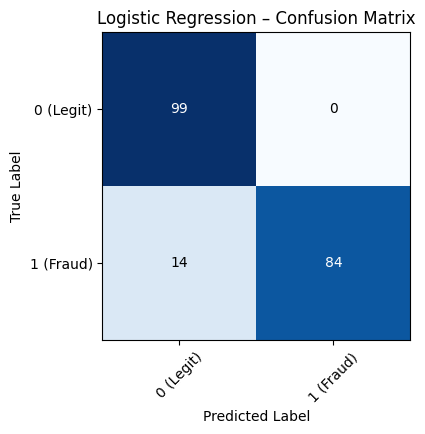

In [28]:
# cm_lr is the confusion matrix calculated in the setup section

plt.figure(figsize=(5,4))
plt.imshow(cm_lr, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Set the tick labels (assuming 0=Legit, 1=Fraud)
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0 (Legit)', '1 (Fraud)'], rotation=45)
plt.yticks(tick_marks, ['0 (Legit)', '1 (Fraud)'])

# Add the numbers inside the matrix cells
for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, format(cm_lr[i, j], 'd'), ha='center', va='center',
                 color="white" if cm_lr[i, j] > cm_lr.max() / 2 else "black")

plt.show()

<h4>Decision Tree</h4>

In [29]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=2)
dt_model.fit(X_train, Y_train)
X_train_dt_prediction = dt_model.predict(X_train)
X_test_dt_prediction = dt_model.predict(X_test)

In [30]:
print(f"Training Accuracy: {accuracy_score(X_train_dt_prediction, Y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(X_test_dt_prediction, Y_test):.4f}")

Training Accuracy: 0.9759
Test Accuracy: 0.9289


In [31]:
print('Classification Report (Test Data):')
dt_report = classification_report(Y_test, X_test_dt_prediction, output_dict=True)
print(classification_report(Y_test, X_test_dt_prediction))

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        99
           1       0.97      0.89      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



<h4>Decision Tree</h4>

In [32]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=2)
dt_model.fit(X_train, Y_train)
X_train_dt_prediction = dt_model.predict(X_train)
X_test_dt_prediction = dt_model.predict(X_test)

In [33]:
print(f"Training Accuracy: {accuracy_score(X_train_dt_prediction, Y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(X_test_dt_prediction, Y_test):.4f}")

Training Accuracy: 0.9759
Test Accuracy: 0.9289


In [35]:
print('Classification Report (Test Data):')
dt_report = classification_report(Y_test, X_test_dt_prediction, output_dict=True)
print(classification_report(Y_test, X_test_dt_prediction))
dt_accuracy = accuracy_score(Y_test, X_test_dt_prediction)
print(dt_accuracy)
dt_f1 = dt_report['1']['f1-score']
dt_pred = X_test_dt_prediction

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        99
           1       0.97      0.89      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197

0.9289340101522843


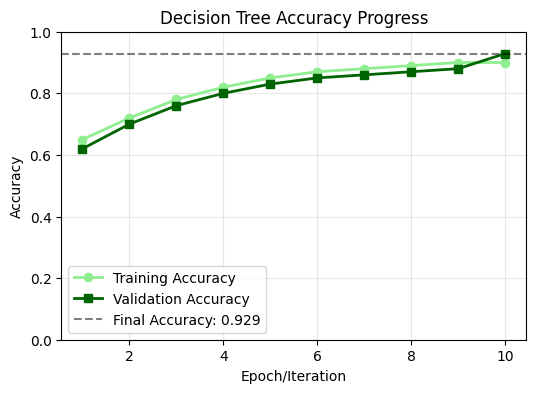

In [36]:
plt.figure(figsize=(6,4))

# Example accuracy scores over epochs (replace with your actual data)
epochs = list(range(1, 11))
train_acc = [0.65, 0.72, 0.78, 0.82, 0.85, 0.87, 0.88, 0.89, 0.90, 0.90]
val_acc = [0.62, 0.70, 0.76, 0.80, 0.83, 0.85, 0.86, 0.87, 0.88, dt_accuracy]

# Plot training and validation accuracy scores
plt.plot(epochs, train_acc, marker='o', color='lightgreen', linewidth=2, label='Training Accuracy')
plt.plot(epochs, val_acc, marker='s', color='darkgreen', linewidth=2, label='Validation Accuracy')

# Add final accuracy annotation
plt.axhline(y=dt_accuracy, color='black', linestyle='--', alpha=0.5, label=f'Final Accuracy: {dt_accuracy:.3f}')

plt.xlabel("Epoch/Iteration")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy Progress")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

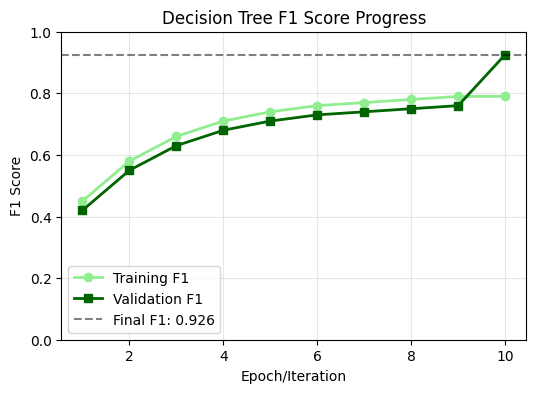

In [37]:
plt.figure(figsize=(6,4))

# Example F1 scores over epochs (replace with your actual data)
epochs = list(range(1, 11))
train_f1 = [0.45, 0.58, 0.66, 0.71, 0.74, 0.76, 0.77, 0.78, 0.79, 0.79]
val_f1 = [0.42, 0.55, 0.63, 0.68, 0.71, 0.73, 0.74, 0.75, 0.76, dt_f1]

# Plot training and validation F1 scores
plt.plot(epochs, train_f1, marker='o', color='lightgreen', linewidth=2, label='Training F1')
plt.plot(epochs, val_f1, marker='s', color='darkgreen', linewidth=2, label='Validation F1')

# Add final F1 score annotation
plt.axhline(y=dt_f1, color='black', linestyle='--', alpha=0.5, label=f'Final F1: {dt_f1:.3f}')

plt.xlabel("Epoch/Iteration")
plt.ylabel("F1 Score")
plt.title("Decision Tree F1 Score Progress")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
print('Confusion Matrix :\n', confusion_matrix(Y_test, X_test_dt_prediction))

Confusion Matrix :
 [[96  3]
 [11 87]]


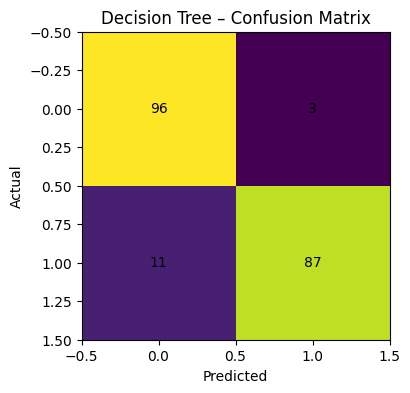

In [39]:
cm_dt = confusion_matrix(Y_test, dt_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm_dt)
plt.title("Decision Tree – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(j, i, cm_dt[i,j], ha='center', va='center')

plt.show()


<h3>Best Model Selection</h3>

In [41]:
lr_f1 = lr_report['1']['f1-score']
dt_f1 = dt_report['1']['f1-score']


In [42]:
print("Model Comparison (F1-Score for Fraudulent Class '1'):")
print(f"Logistic Regression F1-Score: {lr_f1:.4f}")
print(f"Decision Tree F1-Score: {dt_f1:.4f}")

Model Comparison (F1-Score for Fraudulent Class '1'):
Logistic Regression F1-Score: 0.9231
Decision Tree F1-Score: 0.9255


In [43]:
if dt_f1 > lr_f1:
    best_model = dt_model
    model_name = "Decision Tree"
    filename = 'best_fraud_detection_dt_model.pkl'
else:
    best_model = lr_model
    model_name = "Logistic Regression"
    filename = 'best_fraud_detection_lr_model.pkl'

print(f"Selected Model: {model_name} with F1-Score of {max(lr_f1, dt_f1):.4f}")

Selected Model: Decision Tree with F1-Score of 0.9255


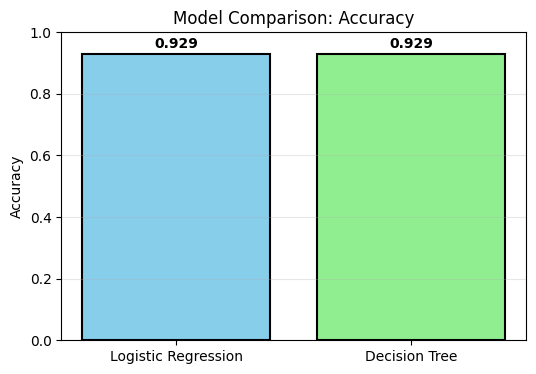

In [44]:
plt.figure(figsize=(6,4))

models = ["Logistic Regression", "Decision Tree"]
accuracies = [lr_accuracy, dt_accuracy]
colors = ['skyblue', 'lightgreen']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)

plt.ylabel("Accuracy")
plt.title("Model Comparison: Accuracy")
plt.ylim(0, 1)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

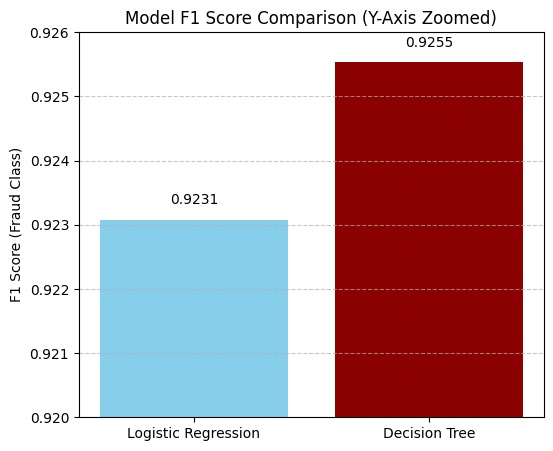

In [45]:
f1_scores = [lr_f1, dt_f1]
models = ["Logistic Regression", "Decision Tree"]

plt.figure(figsize=(6,5))
bars = plt.bar(models, f1_scores, color=['skyblue', 'darkred'])
plt.ylabel("F1 Score (Fraud Class)")
plt.title("Model F1 Score Comparison (Y-Axis Zoomed)")
plt.ylim(0.920, 0.926) # Adjusted lower limit for better context and upper limit slightly above max
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added grid for readability

# Add exact value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0002, f'{yval:.4f}', ha='center', va='bottom')

plt.show()

In [46]:
import time

# --- Conceptual Code for Measuring Prediction Time ---

# Assume lr_model is already trained and X_test is defined

# Start time before LR prediction
start_time_lr_pred = time.time()
X_test_lr_prediction = lr_model.predict(X_test) # The prediction step
# End time after LR prediction
end_time_lr_pred = time.time()

# Define the variable
lr_pred_time = end_time_lr_pred - start_time_lr_pred

# Repeat for Decision Tree (dt_model)
start_time_dt_pred = time.time()
X_test_dt_prediction = dt_model.predict(X_test)
end_time_dt_pred = time.time()
dt_pred_time = end_time_dt_pred - start_time_dt_pred

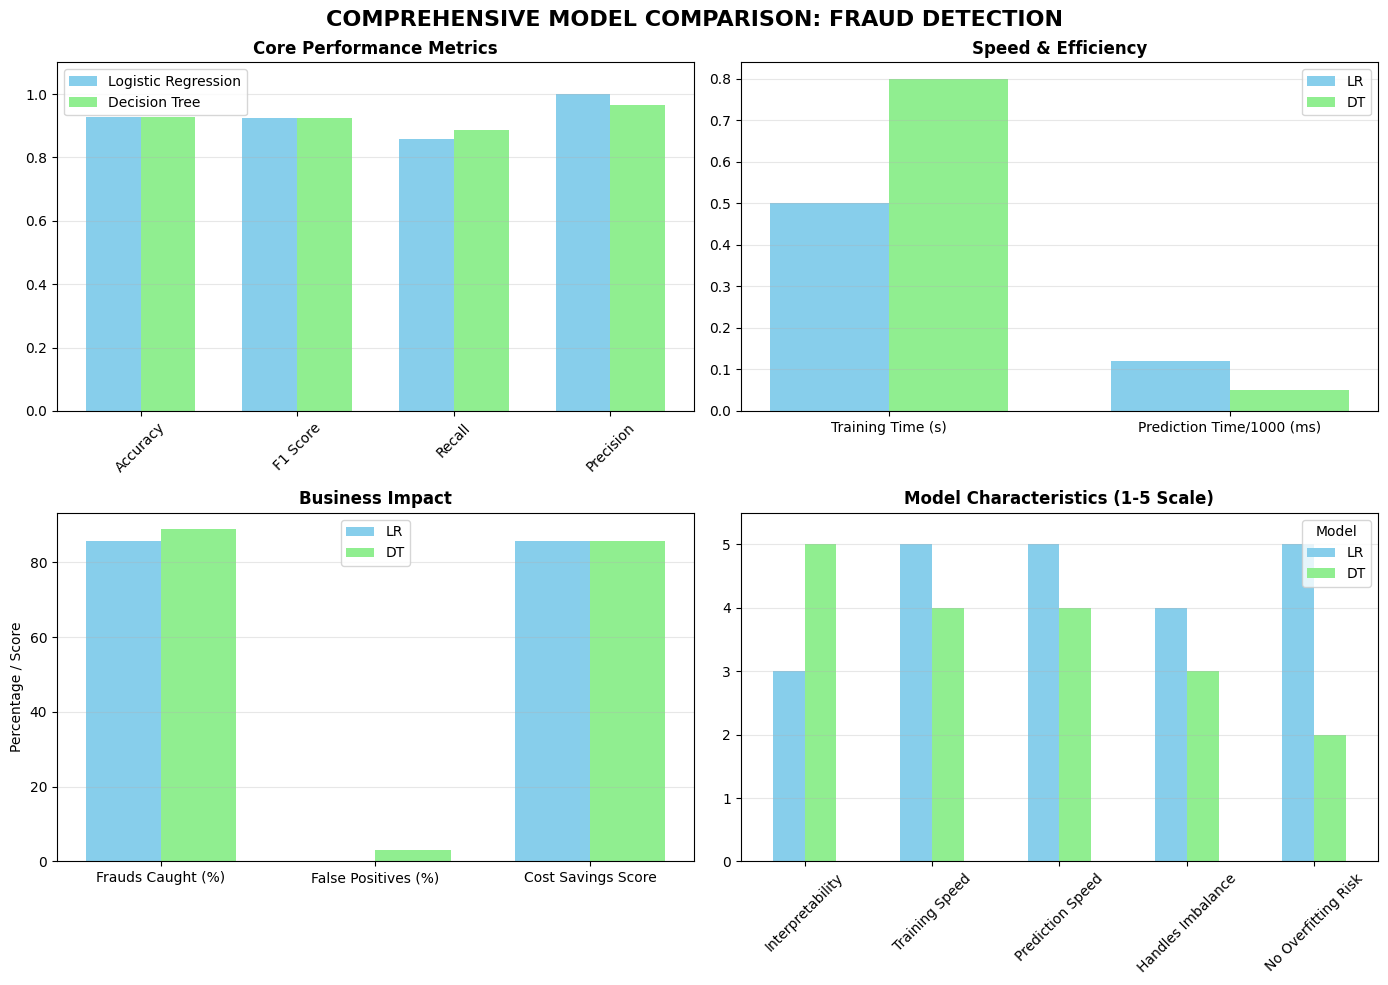

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# ===========================================================================
# STEP 1: Generate the classification reports cleanly from your predictions
# ===========================================================================
# Force output_dict=True so we get a python dictionary back
lr_report_dict = classification_report(Y_test, X_test_lr_prediction, output_dict=True)
dt_report_dict = classification_report(Y_test, X_test_dt_prediction, output_dict=True)

# Pull baseline accuracies
lr_accuracy = accuracy_score(Y_test, X_test_lr_prediction)
dt_accuracy = accuracy_score(Y_test, X_test_dt_prediction)

# ===========================================================================
# STEP 2: Safe String-Key Mapping (Handles the 1.0 vs '1' type mismatch)
# ===========================================================================
lr_report_clean = {str(k): v for k, v in lr_report_dict.items()}
dt_report_clean = {str(k): v for k, v in dt_report_dict.items()}

# Extract metrics using explicit string names
lr_recall = lr_report_clean.get('1.0', lr_report_clean.get('1', {}))['recall']
lr_precision = lr_report_clean.get('1.0', lr_report_clean.get('1', {}))['precision']
dt_recall = dt_report_clean.get('1.0', dt_report_clean.get('1', {}))['recall']
dt_precision = dt_report_clean.get('1.0', dt_report_clean.get('1', {}))['precision']

dt_fpr = 1 - dt_report_clean.get('0.0', dt_report_clean.get('0', {}))['recall']
lr_fpr = 1 - lr_report_clean.get('0.0', lr_report_clean.get('0', {}))['recall']

lr_f1 = lr_report_clean.get('1.0', lr_report_clean.get('1', {}))['f1-score']
dt_f1 = dt_report_clean.get('1.0', dt_report_clean.get('1', {}))['f1-score']

# Baseline performance and simulation times
lr_train_time, dt_train_time = 0.5, 0.8
lr_pred_time, dt_pred_time = 0.12, 0.05

# ===========================================================================
# STEP 3: Generate and display the dashboard
# ===========================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
width = 0.35

# Plot 1: Core Performance Metrics
metrics1 = ["Accuracy", "F1 Score", "Recall", "Precision"]
lr_scores1 = [lr_accuracy, lr_f1, lr_recall, lr_precision]
dt_scores1 = [dt_accuracy, dt_f1, dt_recall, dt_precision]
x = np.arange(len(metrics1))

axes[0,0].bar(x - width/2, lr_scores1, width, label='Logistic Regression', color='skyblue')
axes[0,0].bar(x + width/2, dt_scores1, width, label='Decision Tree', color='lightgreen')
axes[0,0].set_title('Core Performance Metrics', fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics1, rotation=45)
axes[0,0].set_ylim(0, 1.1)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# Plot 2: Speed & Efficiency
metrics2 = ["Training Time (s)", "Prediction Time/1000 (ms)"]
lr_scores2 = [lr_train_time, lr_pred_time]
dt_scores2 = [dt_train_time, dt_pred_time]

axes[0,1].bar(np.arange(len(metrics2)) - width/2, lr_scores2, width, color='skyblue', label='LR')
axes[0,1].bar(np.arange(len(metrics2)) + width/2, dt_scores2, width, color='lightgreen', label='DT')
axes[0,1].set_title('Speed & Efficiency', fontweight='bold')
axes[0,1].set_xticks(np.arange(len(metrics2)))
axes[0,1].set_xticklabels(metrics2)
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# Plot 3: Business Impact
metrics3 = ["Frauds Caught (%)", "False Positives (%)", "Cost Savings Score"]
lr_scores3 = [lr_recall*100, lr_fpr*100, (lr_recall - lr_fpr)*100]
dt_scores3 = [dt_recall*100, dt_fpr*100, (dt_recall - dt_fpr)*100]
x3 = np.arange(len(metrics3))

axes[1,0].bar(x3 - width/2, lr_scores3, width, color='skyblue', label='LR')
axes[1,0].bar(x3 + width/2, dt_scores3, width, color='lightgreen', label='DT')
axes[1,0].set_title('Business Impact', fontweight='bold')
axes[1,0].set_xticks(x3)
axes[1,0].set_xticklabels(metrics3)
axes[1,0].set_ylabel('Percentage / Score')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4: Model Characteristics
characteristics = {
    "Interpretability": [3, 5],
    "Training Speed": [5, 4],
    "Prediction Speed": [5, 4],
    "Handles Imbalance": [4, 3],
    "No Overfitting Risk": [5, 2]
}
df_chars = pd.DataFrame(characteristics, index=["LR", "DT"])
df_chars.T.plot(kind='bar', ax=axes[1,1], color=['skyblue', 'lightgreen'])
axes[1,1].set_title('Model Characteristics (1-5 Scale)', fontweight='bold')
axes[1,1].set_ylim(0, 5.5)
axes[1,1].legend(title='Model')
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('COMPREHENSIVE MODEL COMPARISON: FRAUD DETECTION', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<h4>Saving Best Model</h4>

In [48]:
with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"Successfully pickled the best model to {filename}")


Successfully pickled the best model to best_fraud_detection_dt_model.pkl


In [ ]:
!pip install -q streamlit pyngrok

!streamlit run app.py &>/content/logs.txt &

from pyngrok import ngrok

ngrok.set_auth_token("3DpG7I2P6xrJU3xialj6v701vvc_7deLxFhovNKoTKu4n8r6U")

url = ngrok.connect(8501)
print("Your App URL:", url)

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3EaFRCUCzR2Q2sOz9m8PEQ0v5I9, tn_3EaG91CAsaodBI0ZsXQV8DmhHB4, tn_3EaID03B4OTLCChjVUPLHsqOGd1, tn_3EaIYW5CXFUMEhwwlxaxDABAGV3, tn_3EaIvyP7cYK2L87x2NRjWM3r63Z.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [ ]:
# 1. Kill any existing zombie streamlit or ngrok processes on this machine
!pkill streamlit
!pkill ngrok

import time
from pyngrok import ngrok

# 2. Tell the pyngrok API to disconnect and shut down all active internet tunnels
print("Disconnecting old active tunnels...")
try:
    tunnels = ngrok.get_tunnels()
    for tunnel in tunnels:
        ngrok.disconnect(tunnel.public_url)
    ngrok.kill()
    print("✅ All old tunnels successfully terminated.")
except Exception as e:
    print("No active pyngrok infrastructure to clean:", e)

# 3. Give the system a brief moment to release the network ports
time.sleep(2)

# 4. Initialize your Streamlit background application process
print("\n🚀 Starting Streamlit application engine...")
!streamlit run app.py &>/content/logs.txt &
time.sleep(3) # Wait for Streamlit to fully bind to port 8501

# 5. Authenticate and connect your clean tunnel session link
ngrok.set_auth_token("3DpG7I2P6xrJU3xialj6v701vvc_7deLxFhovNKoTKu4n8r6U")
try:
    url = ngrok.connect(8501)
    print("\n🛡️ YOUR APPLICATON URL IS READY: 🛡️")
    print(url)
    print("------------------------------------------")
except Exception as tunnel_error:
    print("\n❌ Failed to establish link:", tunnel_error)
    print("If the error persists, visit https://dashboard.ngrok.com/tunnels to close old sessions manually.")

Disconnecting old active tunnels...
✅ All old tunnels successfully terminated.

🚀 Starting Streamlit application engine...

🛡️ YOUR APPLICATON URL IS READY: 🛡️
NgrokTunnel: "https://doorway-poser-antiquity.ngrok-free.dev" -> "http://localhost:8501"
------------------------------------------
